# TRANSFER LEARNING FOR COMPUTER VISION PROJECT

## Импорт необходимых библиотек и зависимостей

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory
from typing import Dict, List, Optional, Tuple, Any
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_auc_score, roc_curve, precision_recall_curve, matthews_corrcoef
from torchmetrics import Accuracy, Precision, Recall, F1Score, MatthewsCorrCoef, AUROC, AveragePrecision
import seaborn as sns
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()

## Загрузка необходимых данных

### Деархивация архива для примера

In [2]:
import shutil
shutil.unpack_archive('./../data/hymenoptera_data/hymenoptera_data.zip', 'hymenoptera_data', 'zip')

ReadError: ./../data/hymenoptera_data/hymenoptera_data.zip is not a zip file

### Получение данных для работы

In [5]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms: Dict[str, transforms.Compose] = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir: str = './../data/hymenoptera_data'
image_datasets: Dict[str, datasets.ImageFolder] = {
    x: datasets.ImageFolder(
        os.path.join(data_dir, x),
        data_transforms[x]
    )
    for x in ['train', 'val']
}
dataloaders: Dict[str, torch.utils.data.DataLoader] = {
    x: torch.utils.data.DataLoader(
        image_datasets[x], 
        batch_size=4,
        shuffle=True, 
        num_workers=4
    )
    for x in ['train', 'val']
}
dataset_sizes: Dict[str, int] = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names: List[str] = image_datasets['train'].classes

# device: str = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
device: str = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


## Визуализация изображений из датасета

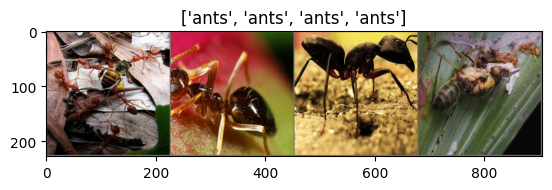

In [6]:
def imshow(
    inp: torch.Tensor, 
    title: str = None
) -> None:
    """Display image for Tensor."""
    inp: np.ndarray = inp.numpy().transpose((1, 2, 0))
    mean: np.ndarray = np.array([0.485, 0.456, 0.406])
    std: np.ndarray = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

inputs: torch.Tensor
classes: torch.Tensor
inputs, classes = next(iter(dataloaders['train']))
out: torch.Tensor = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[x] for x in classes])

## Функции для построения матрицы возмущений и визуализации тренировочных метрик

In [7]:
import numpy.typing as npt

def plot_confusion_matrix(
    labels: List[int], 
    preds: List[int], 
    class_names: List[str]
) -> None:
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        xticklabels=class_names, 
        yticklabels=class_names
    )
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

def plot_training_metrics(
    metrics: Dict[str, List[float]], 
    learning_rates: List[float], 
    val_metrics: Dict[str, List[float]], 
    plot_roc_pr: bool = True
) -> None:
    epochs = range(len(metrics['train_loss']))

    # Convert metrics to numpy arrays for plotting
    train_loss: npt.NDArray[np.float64] = np.array(metrics['train_loss'])
    val_loss: npt.NDArray[np.float64] = np.array(metrics['val_loss'])
    train_acc: npt.NDArray[np.float64] = np.array(metrics['train_acc'])
    val_acc: npt.NDArray[np.float64] = np.array(metrics['val_acc'])

    # Plot Loss
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label='Train Loss', color='#1f77b4')
    plt.plot(epochs, val_loss, label='Validation Loss', color='#ff7f0e')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label='Train Accuracy', color='#1f77b4')
    plt.plot(epochs, val_acc, label='Validation Accuracy', color='#ff7f0e')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Plot Learning Rate
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, learning_rates, label='Learning Rate', color='#2ca02c')
    plt.title('Learning Rate Schedule')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot additional validation metrics
    if val_metrics:
        # Sklearn metrics
        plt.figure(figsize=(12, 8))
        plt.subplot(2, 2, 1)
        plt.plot(epochs, val_metrics.get('precision_skl', [0] * len(epochs)), label='Precision', color='#1f77b4')
        plt.plot(epochs, val_metrics.get('recall_skl', [0] * len(epochs)), label='Recall', color='#ff7f0e')
        plt.plot(epochs, val_metrics.get('f1_skl', [0] * len(epochs)), label='F1', color='#2ca02c')
        plt.title('Precision, Recall, and F1 Score (Sklearn)')
        plt.xlabel('Epoch')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True)

        plt.subplot(2, 2, 2)
        plt.plot(epochs, val_metrics.get('specificity_skl', [0] * len(epochs)), label='Specificity', color='#d62728')
        plt.plot(epochs, val_metrics.get('mcc_skl', [0] * len(epochs)), label='MCC', color='#9467bd')
        plt.title('Specificity and MCC (Sklearn)')
        plt.xlabel('Epoch')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True)

        # Torchmetrics metrics
        plt.figure(figsize=(12, 8))
        plt.subplot(2, 2, 1)
        plt.plot(epochs, val_metrics.get('precision_torch', [0] * len(epochs)), label='Precision', color='#1f77b4')
        plt.plot(epochs, val_metrics.get('recall_torch', [0] * len(epochs)), label='Recall', color='#ff7f0e')
        plt.plot(epochs, val_metrics.get('f1_torch', [0] * len(epochs)), label='F1', color='#2ca02c')
        plt.plot(epochs, val_metrics.get('accuracy_torch', [0] * len(epochs)), label='Accuracy', color='#ff9896')
        plt.title('Precision, Recall, F1, and Accuracy (Torchmetrics)')
        plt.xlabel('Epoch')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True)

        plt.subplot(2, 2, 2)
        plt.plot(epochs, val_metrics.get('mcc_torch', [0] * len(epochs)), label='MCC', color='#9467bd')
        plt.title('MCC (Torchmetrics)')
        plt.xlabel('Epoch')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True)

        if plot_roc_pr and len(val_metrics.get('roc_auc_skl', [])) > 0 and len(val_metrics.get('roc_auc_torch', [])) > 0:
            # Sklearn ROC and PR
            plt.figure(figsize=(12, 5))
            plt.subplot(1, 2, 1)
            plt.plot(epochs, val_metrics.get('roc_auc_skl', [0] * len(epochs)), label='ROC-AUC', color='#8c564b')
            plt.title('ROC-AUC Score (Sklearn)')
            plt.xlabel('Epoch')
            plt.ylabel('ROC-AUC')
            plt.legend()
            plt.grid(True)

            plt.subplot(1, 2, 2)
            plt.plot(epochs, val_metrics.get('pr_auc_skl', [0] * len(epochs)), label='PR-AUC', color='#e377c2')
            plt.title('PR-AUC Score (Sklearn)')
            plt.xlabel('Epoch')
            plt.ylabel('PR-AUC')
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

            # Torchmetrics ROC and PR
            plt.figure(figsize=(12, 5))
            plt.subplot(1, 2, 1)
            plt.plot(epochs, val_metrics.get('roc_auc_torch', [0] * len(epochs)), label='ROC-AUC', color='#8c564b')
            plt.title('ROC-AUC Score (Torchmetrics)')
            plt.xlabel('Epoch')
            plt.ylabel('ROC-AUC')
            plt.legend()
            plt.grid(True)

            plt.subplot(1, 2, 2)
            plt.plot(epochs, val_metrics.get('pr_auc_torch', [0] * len(epochs)), label='PR-AUC', color='#e377c2')
            plt.title('PR-AUC Score (Torchmetrics)')
            plt.xlabel('Epoch')
            plt.ylabel('PR-AUC')
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()
        else:
            plt.tight_layout()
            plt.show()

## Тренировка модели на файлах из датасета

### Информация о LR-Sheduler

* class torch.optim.lr_scheduler.LRScheduler(optimizer, last_epoch=-1)[source]
*  Base class for all learning rate schedulers.

* Subclasses implement get_lr() and optionally override step() to define scheduling behavior.

* Parameters:
- optimizer (Optimizer) – The optimizer this scheduler will adjust the learning rates of.
- last_epoch (int) – Index of the last epoch seen by the scheduler. Use -1 (default) to initialize the scheduler. Only use a non-default value when restoring this scheduler from a saved checkpoint.

In [8]:
def train_model(
    model_arch: nn.Module,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    scheduler: lr_scheduler._LRScheduler,
    num_epochs: int = 25,
    patience: int = 5
) -> Tuple[nn.Module, Dict[str, List[float]], List[float], Dict[str, List[float]]]:
    since: float = time.time()
    best_acc: float = 0.0
    best_loss: float = float('inf')
    epochs_no_improve: int = 0
    early_stop: bool = False

    accuracy = Accuracy(task="binary").to(device)
    precision = Precision(task="binary").to(device)
    recall = Recall(task="binary").to(device)
    f1 = F1Score(task="binary").to(device)
    mcc = MatthewsCorrCoef(task="binary").to(device)
    auroc = AUROC(task="binary").to(device)
    pr_auc = AveragePrecision(task="binary").to(device)

    # Lists to store metrics for plotting
    train_losses: List[float] = []
    val_losses: List[float] = []
    train_accuracies: List[float] = []
    val_accuracies: List[float] = []
    learning_rates: List[float] = []
    val_metrics: Dict[str, List[float]] = {
        'precision_skl': [], 'recall_skl': [], 'f1_skl': [], 'specificity_skl': [], 'mcc_skl': [], 'roc_auc_skl': [], 'pr_auc_skl': [],
        'accuracy_torch': [], 'precision_torch': [], 'recall_torch': [], 'f1_torch': [], 'mcc_torch': [], 'roc_auc_torch': [], 'pr_auc_torch': []
    }

    # Create a temporary directory to save training checkpoint
    with TemporaryDirectory() as tempdir:
        best_model_params_path: str = os.path.join(tempdir, 'best_model_params.pt')
        torch.save(model_arch.state_dict(), best_model_params_path)
        for epoch in range(num_epochs):
            if early_stop:
                print("Early stopping triggered.")
                break
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)
            current_lr: float = optimizer.param_groups[0]['lr']
            learning_rates.append(current_lr)
            print(f'Learning Rate: {current_lr:.6f}')

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model_arch.train() # Set model to training mode
                else:
                    model_arch.eval() # Set model to evaluate mode

                running_loss: float = 0.0
                running_corrects: float = 0.0
                all_preds: List[int] = []
                all_labels: List[int] = []
                all_probs: List[float] = []  # For ROC and PR curves
                all_probs_skl: List[float] = []

                accuracy.reset()
                precision.reset()
                recall.reset()
                f1.reset()
                mcc.reset()
                auroc.reset()
                pr_auc.reset()

                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs: torch.Tensor = model_arch(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss: torch.Tensor = criterion(outputs, labels)
                        probs: torch.Tensor = torch.softmax(outputs, dim=1)[:, 1]
                        probs_skl: np.ndarray = torch.softmax(outputs, dim=1)[:, 1].detach().cpu().numpy()

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data).item()
                    if phase == 'val':
                        all_preds.extend(preds.cpu().numpy())
                        all_labels.extend(labels.cpu().numpy())
                        all_probs.extend(probs)
                        all_probs_skl.extend(probs_skl)

                    accuracy.update(preds, labels)
                    precision.update(preds, labels)
                    recall.update(preds, labels)
                    f1.update(preds, labels)
                    mcc.update(preds, labels)
                    auroc.update(probs, labels)
                    pr_auc.update(probs, labels)

                if phase == 'train':
                    scheduler.step()

                epoch_loss: float = running_loss / dataset_sizes[phase]
                epoch_acc: float = running_corrects / dataset_sizes[phase]

                if phase == 'train':
                    train_losses.append(epoch_loss)
                    train_accuracies.append(epoch_acc)
                else:
                    val_losses.append(epoch_loss)
                    val_accuracies.append(epoch_acc)
                    # Early stopping check
                    if epoch_loss < best_loss:
                        best_loss: float = epoch_loss
                        best_acc: float = epoch_acc
                        epochs_no_improve: int = 0
                        torch.save(model_arch.state_dict(), best_model_params_path)
                    else:
                        epochs_no_improve += 1
                        if epochs_no_improve >= patience:
                            early_stop = True

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                if phase == 'val':
                    precision_skl, recall_skl, f1_skl, _ = precision_recall_fscore_support(
                        all_labels, all_preds, average='binary', zero_division=0
                    )
                    cm: np.ndarray = confusion_matrix(all_labels, all_preds)
                    tn, fp, fn, tp = cm.ravel()
                    specificity_skl: float = tn / (tn + fp) if (tn + fp) > 0 else 0.0
                    mcc_skl: float = matthews_corrcoef(all_labels, all_preds)
                    roc_auc_skl: float = roc_auc_score(all_labels, all_probs_skl)
                    precision_curve, recall_curve, _ = precision_recall_curve(all_labels, all_probs_skl)
                    pr_auc_skl: npt.NDArray[np.float64] = np.trapezoid(recall_curve, precision_curve)

                    val_metrics['precision_skl'].append(precision_skl)
                    val_metrics['recall_skl'].append(recall_skl)
                    val_metrics['f1_skl'].append(f1_skl)
                    val_metrics['specificity_skl'].append(specificity_skl)
                    val_metrics['mcc_skl'].append(mcc_skl)
                    val_metrics['roc_auc_skl'].append(roc_auc_skl)
                    val_metrics['pr_auc_skl'].append(pr_auc_skl)

                    print(f'{phase} Precision_skl: {precision_skl:.4f}, Recall_skl: {recall_skl:.4f}, F1_skl: {f1_skl:.4f}')
                    print(f'{phase} Specificity_skl: {specificity_skl:.4f}, MCC_skl: {mcc_skl:.4f}')
                    print(f'{phase} ROC-AUC_skl: {roc_auc_skl:.4f}, PR-AUC_skl: {pr_auc_skl:.4f}')

                    val_metrics['accuracy_torch'].append(accuracy.compute().item())
                    val_metrics['precision_torch'].append(precision.compute().item())
                    val_metrics['recall_torch'].append(recall.compute().item())
                    val_metrics['f1_torch'].append(f1.compute().item())
                    val_metrics['mcc_torch'].append(mcc.compute().item())
                    val_metrics['roc_auc_torch'].append(auroc.compute().item())
                    val_metrics['pr_auc_torch'].append(pr_auc.compute().item())

                    print(f'{phase} Precision_torch: {val_metrics["precision_torch"][-1]:.4f}, Recall_torch: {val_metrics["recall_torch"][-1]:.4f}, F1_torch: {val_metrics["f1_torch"][-1]:.4f}')
                    print(f'{phase} Accuracy_torch: {val_metrics["accuracy_torch"][-1]:.4f}, MCC_torch: {val_metrics["mcc_torch"][-1]:.4f}')
                    print(f'{phase} ROC-AUC_torch: {val_metrics["roc_auc_torch"][-1]:.4f}, PR-AUC_torch: {val_metrics["pr_auc_torch"][-1]:.4f}')

            print()

        time_elapsed: float = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')
        model_arch.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    if all_preds and all_labels:
            plot_confusion_matrix(all_labels, all_preds, class_names)

    metrics: Dict[str, List[float]] = {
        'train_loss': train_losses,
        'val_loss': val_losses,
        'train_acc': train_accuracies,
        'val_acc': val_accuracies
    }
    return model_arch, metrics, learning_rates, val_metrics

## Визуализация предсказаний модели

In [9]:
def visualize_model(
    model: nn.Module,
    num_images: int = 6
) -> None:
    was_training: bool = model.training
    model.eval()
    images_so_far: int = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs: torch.Tensor = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

## Finetuning the ConvNet

### Load a pretrained model and reset final fully connected layer.

In [10]:
model_ft: nn.Module = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs: int = model_ft.fc.in_features

# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to ``nn.Linear(num_ftrs, len(class_names))``.
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion: nn.Module = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft: optim.Optimizer = optim.SGD(
    model_ft.parameters(), 
    lr=0.001, 
    momentum=0.9
)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler: lr_scheduler._LRScheduler = lr_scheduler.StepLR(
    optimizer_ft, 
    step_size=7, 
    gamma=0.1
)

/home/yamshchikov/ML_practice/Torchvision_core_project/MLvenv/lib/python3.12/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


## Train and evaluate

Epoch 0/199
----------
Learning Rate: 0.001000


train Loss: 0.7542 Acc: 0.6475
val Loss: 0.9722 Acc: 0.6209
val Precision_skl: 1.0000, Recall_skl: 0.3012, F1_skl: 0.4630
val Specificity_skl: 1.0000, MCC_skl: 0.4059
val ROC-AUC_skl: 0.9539, PR-AUC_skl: 0.4216
val Precision_torch: 1.0000, Recall_torch: 0.3012, F1_torch: 0.4630
val Accuracy_torch: 0.6209, MCC_torch: 0.4059
val ROC-AUC_torch: 0.9539, PR-AUC_torch: 0.9643

Epoch 1/199
----------
Learning Rate: 0.001000
train Loss: 0.7959 Acc: 0.6967
val Loss: 0.3068 Acc: 0.8758
val Precision_skl: 0.9211, Recall_skl: 0.8434, F1_skl: 0.8805
val Specificity_skl: 0.9143, MCC_skl: 0.7549
val ROC-AUC_skl: 0.9499, PR-AUC_skl: 0.4172
val Precision_torch: 0.9211, Recall_torch: 0.8434, F1_torch: 0.8805
val Accuracy_torch: 0.8758, MCC_torch: 0.7549
val ROC-AUC_torch: 0.9499, PR-AUC_torch: 0.9600

Epoch 2/199
----------
Learning Rate: 0.001000
train Loss: 0.5364 Acc: 0.7951
val Loss: 0.4023 Acc: 0.8627
val Precision_skl: 0.8370, Recall_skl: 0.9277, F1_skl: 0.8800
val Specificity_skl: 0.7857, MCC_skl

/home/yamshchikov/ML_practice/Torchvision_core_project/MLvenv/lib/python3.12/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


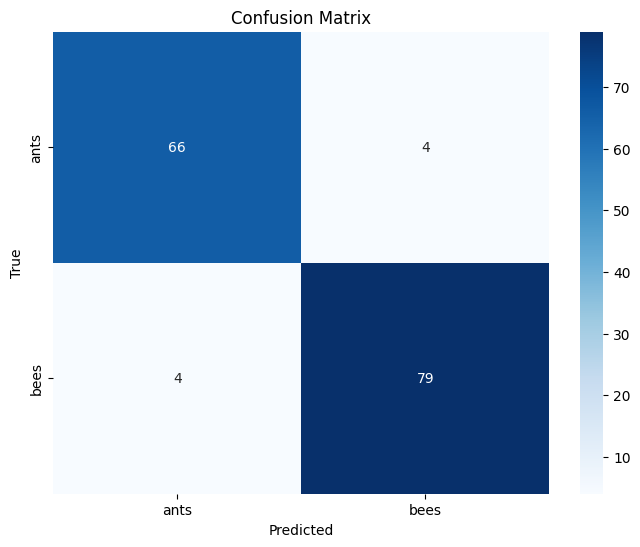

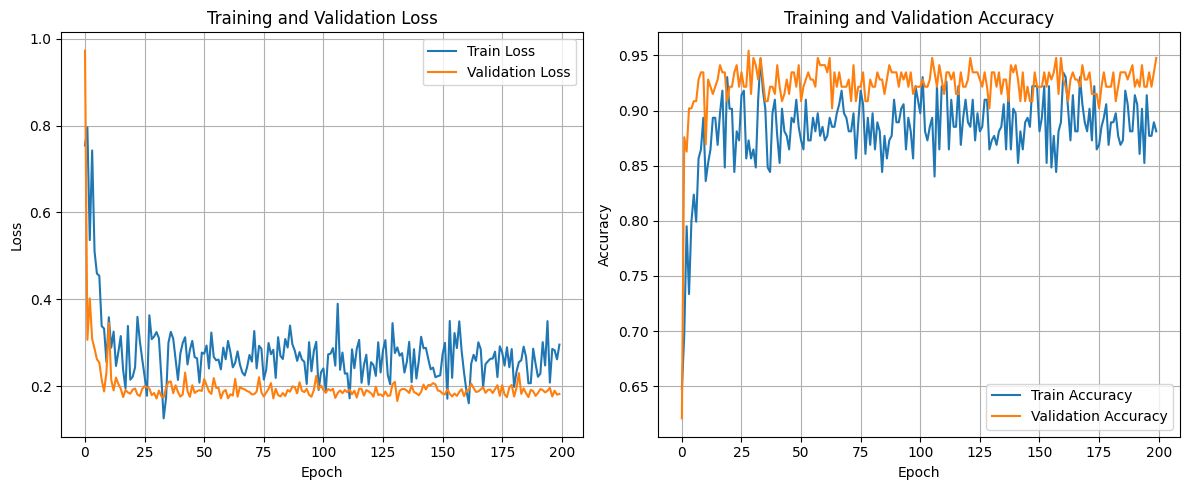

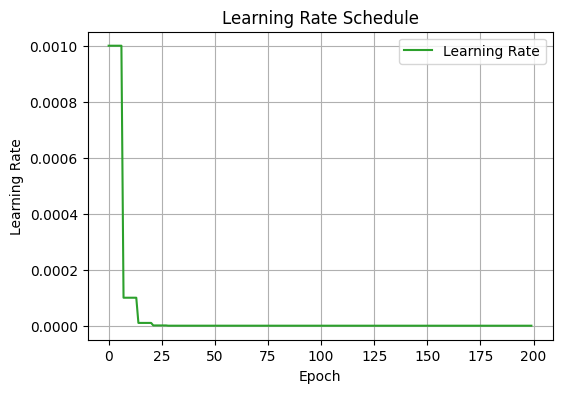

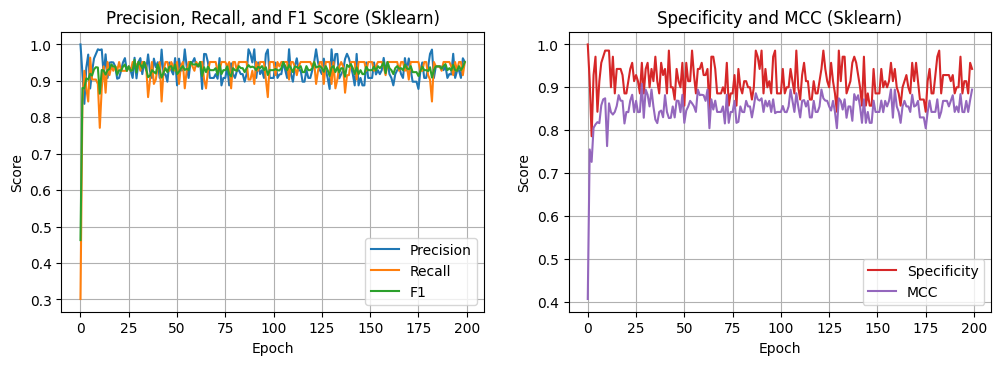

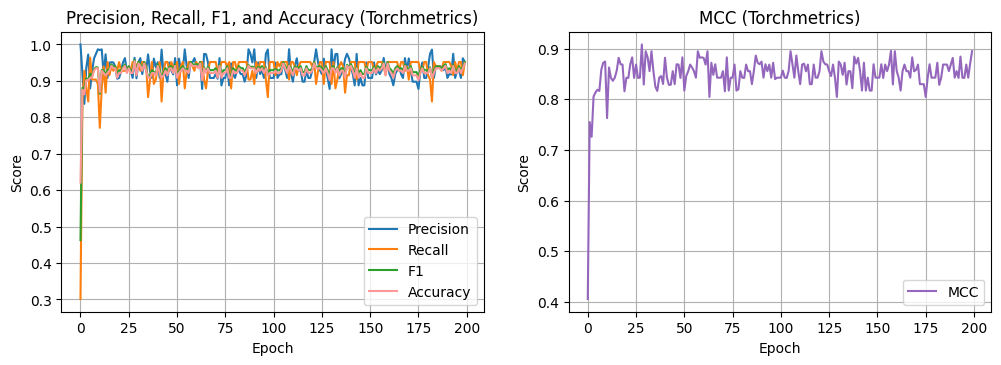

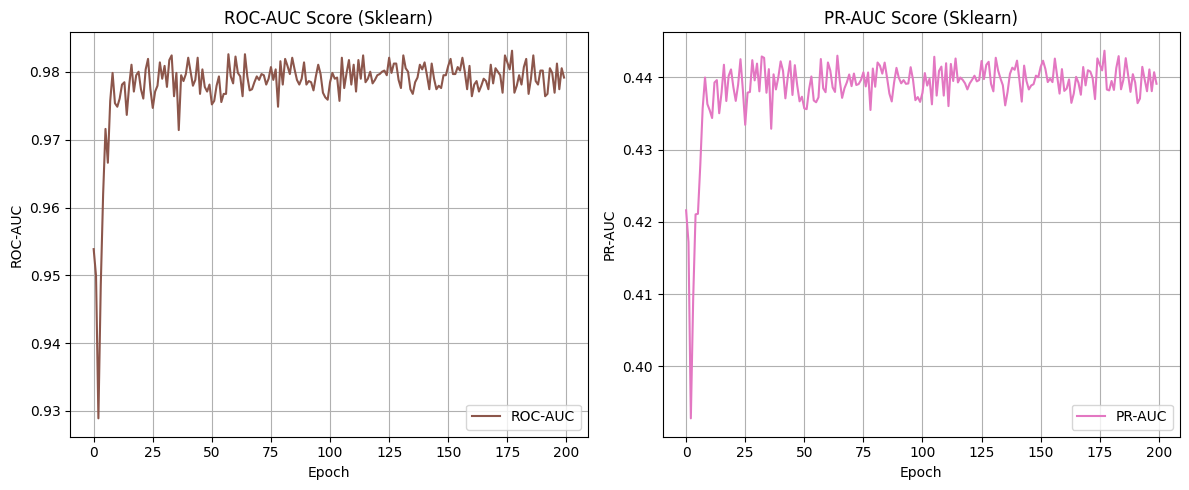

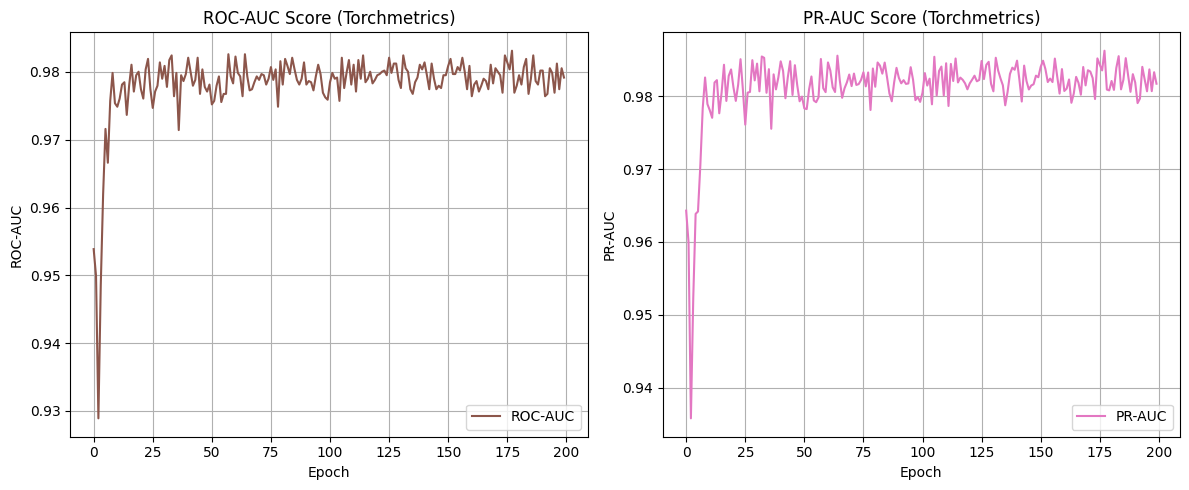

In [11]:
model_ft, metrics, learning_rates, val_metrics = train_model(
    model_ft, 
    criterion, 
    optimizer_ft, 
    exp_lr_scheduler, 
    num_epochs=200, 
    patience=200
)

# Plot training metrics
plot_training_metrics(
    metrics, 
    learning_rates, 
    val_metrics, 
    plot_roc_pr=True
)

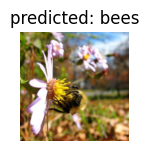

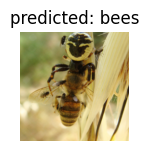

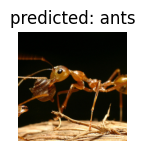

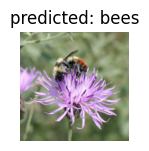

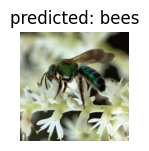

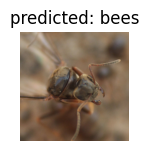

In [12]:
visualize_model(model_ft)

## ConvNet as fixed feature extractor

### Here, we need to freeze all the network except the final layer. We need to set requires_grad = False to freeze the parameters so that the gradients are not computed in backward().

In [13]:
model_conv: nn.Module = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs: int = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion: nn.Module = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv: optim.Optimizer = optim.SGD(
    model_conv.fc.parameters(), 
    lr=0.001, 
    momentum=0.9
)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(
    optimizer_conv, 
    step_size=7, 
    gamma=0.1
)

## Train and evaluate

Epoch 0/199
----------
Learning Rate: 0.001000


train Loss: 0.6138 Acc: 0.6803
val Loss: 0.2353 Acc: 0.9085
val Precision_skl: 0.8876, Recall_skl: 0.9518, F1_skl: 0.9186
val Specificity_skl: 0.8571, MCC_skl: 0.8170
val ROC-AUC_skl: 0.9771, PR-AUC_skl: 0.4385
val Precision_torch: 0.8876, Recall_torch: 0.9518, F1_torch: 0.9186
val Accuracy_torch: 0.9085, MCC_torch: 0.8170
val ROC-AUC_torch: 0.9771, PR-AUC_torch: 0.9811

Epoch 1/199
----------
Learning Rate: 0.001000
train Loss: 0.5163 Acc: 0.7336
val Loss: 0.3643 Acc: 0.8301
val Precision_skl: 0.9672, Recall_skl: 0.7108, F1_skl: 0.8194
val Specificity_skl: 0.9714, MCC_skl: 0.6942
val ROC-AUC_skl: 0.9762, PR-AUC_skl: 0.4380
val Precision_torch: 0.9672, Recall_torch: 0.7108, F1_torch: 0.8194
val Accuracy_torch: 0.8301, MCC_torch: 0.6942
val ROC-AUC_torch: 0.9762, PR-AUC_torch: 0.9806

Epoch 2/199
----------
Learning Rate: 0.001000
train Loss: 1.0142 Acc: 0.6721
val Loss: 0.5308 Acc: 0.7974
val Precision_skl: 0.9815, Recall_skl: 0.6386, F1_skl: 0.7737
val Specificity_skl: 0.9857, MCC_skl

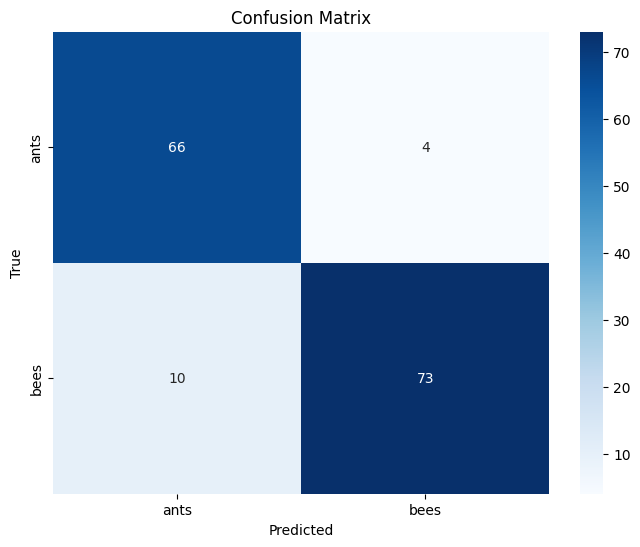

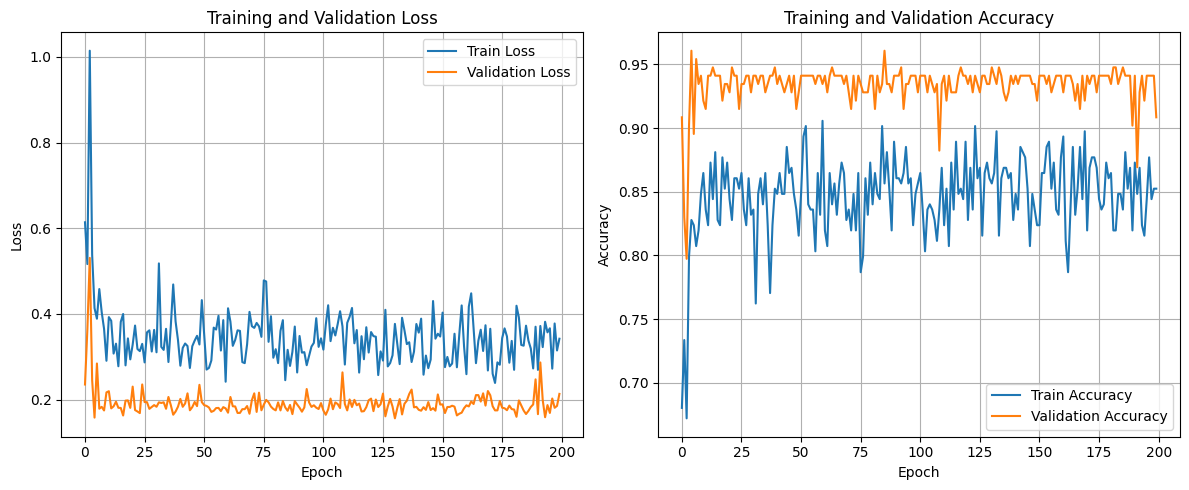

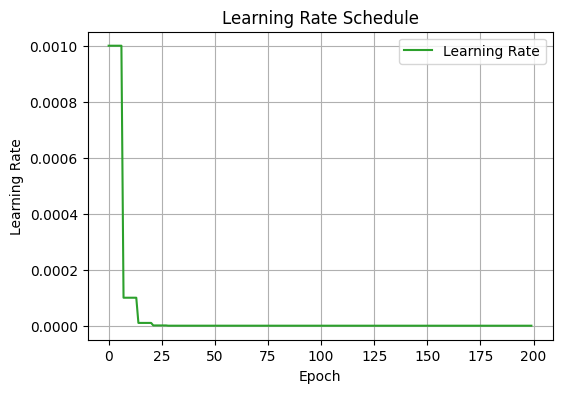

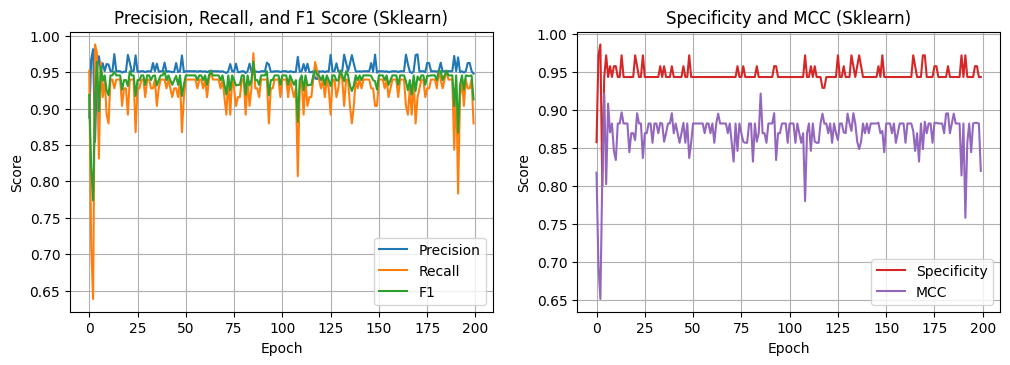

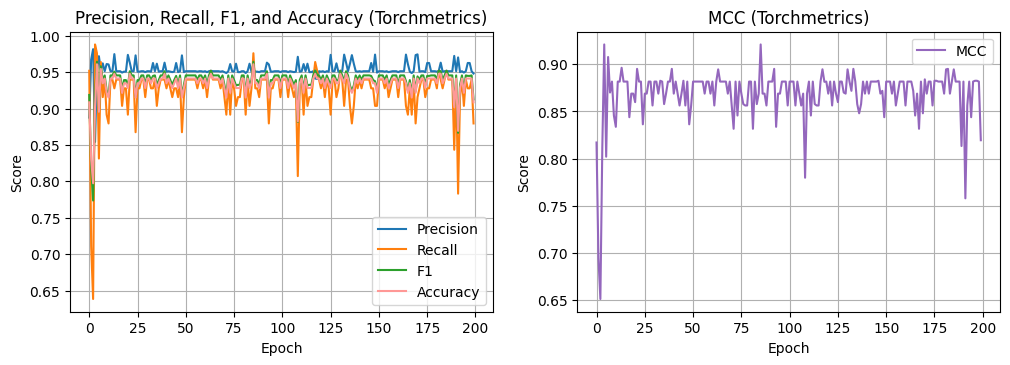

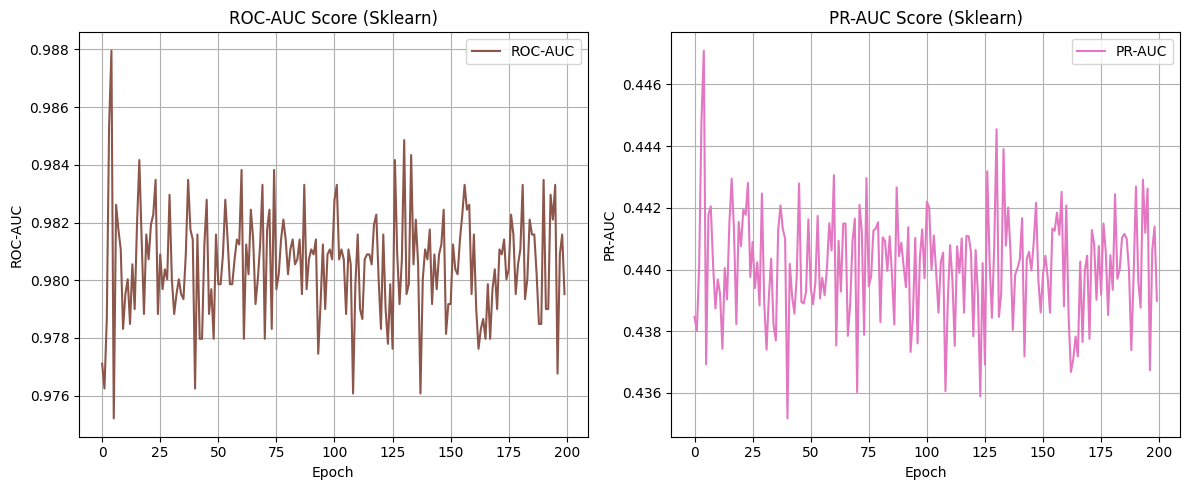

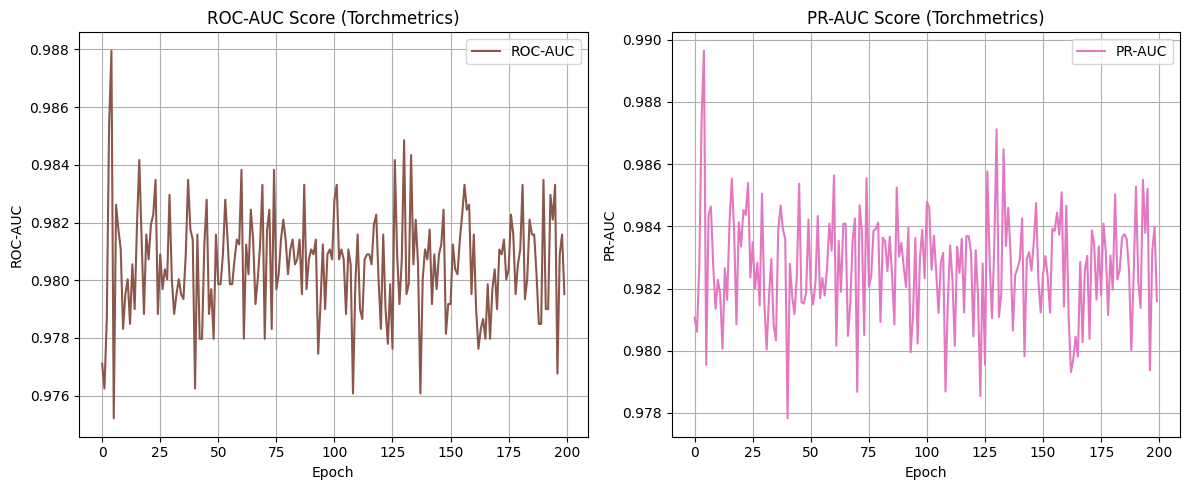

In [14]:
model_conv, metrics, learning_rates, val_metrics = train_model(
    model_conv, 
    criterion, 
    optimizer_conv, 
    exp_lr_scheduler, 
    num_epochs=200, 
    patience=200
)

# Plot training metrics
plot_training_metrics(
    metrics, 
    learning_rates, 
    val_metrics, 
    plot_roc_pr=True
)

## Visualising

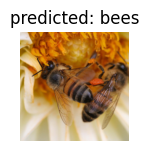

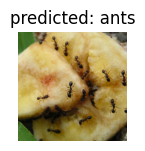

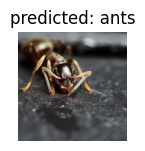

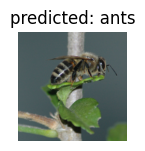

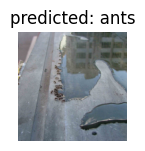

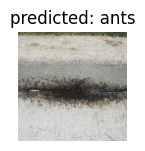

In [15]:
visualize_model(model_conv)

plt.ioff()
plt.show()

## Inference on custom images

In [16]:
def visualize_model_predictions(
    model: nn.Module, 
    img_path: str
) -> None:
    was_training: bool = model.training
    model.eval()

    img: Image.Image = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs: torch.Tensor = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

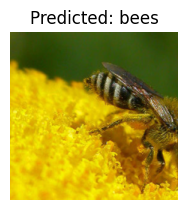

In [17]:
visualize_model_predictions(
    model_conv,
    img_path='./../data/hymenoptera_data/val/bees/26589803_5ba7000313.jpg'
)

plt.ioff()
plt.show()